# Entropy of trial-mode use along LD1

How evenly does a session spread its trials over the 17 trial modes (`trial_modes_proficient.ipynb`), and does that track LD1?

* **Entropy** of a session's mode-usage distribution, normalised by log(17) (0 = one mode only, 1 = all modes equally). Unembedded / background trials are left out.
* **Equal trial counts.** Plug-in entropy is biased low for small samples, and sessions run 400–1500 trials, so each session's entropy is the mean over `N_SUB` random subsamples of `N_TRIALS` trials (the shortest session). Also reported as an effective number of modes, exp(H).
* **Units.** Session-level statistics are pseudo-replicated (mice give 1–13 sessions), so the mouse level (mean over sessions) is the headline.
* **Confounds checked:** session accuracy (disengaged / error modes raise entropy if they are rare), lab (LD1 is lab-confounded: lab-centred version), and session length.
* **Circularity caveat.** LD1 and the trial modes both come from the same syllables (02-10-2026). An LD1–entropy correlation therefore says that the syllable-usage axis LD1 picks out also organises how trials spread over modes; it is not independent evidence the way a GLM-HMM or neural measure would be.

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'Functions' / 'trial_modes.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / 'paper-individuality'))
sys.path.insert(0, str(REPO / 'paper-individuality' / 'GLM-HMM' / 'transition_prediction'))
from Functions import trial_modes as tm
import paper_style as ps
import tp_data as td
ps.use('paper')

PI = REPO / 'paper-individuality'
MODES_FILE = PI / '3_trial_modes' / 'trial_modes_8_k_10_bin_syllables_02-10-2026' / 'trials.pqt'
N_SUB, SEED = 200, 0

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Data

In [2]:
trials = pd.read_parquet(MODES_FILE, columns=['session', 'mouse_name', 'trial_id', 'trial_type', 'trial_cluster',
                                              'embedding_x', 'embedding_y'])
trials['correct'] = (trials['trial_type'].str.split().str[0] == 'correct').astype(float)
lda = td.load_lda()
# only sessions with an LD1 value: they set the subsample size
modes = trials.dropna(subset=['trial_cluster'])
modes = modes[modes['session'].isin(lda['session'])].copy()
modes['trial_cluster'] = modes['trial_cluster'].astype(int)
K = modes['trial_cluster'].nunique()
n_per = modes.groupby('session').size()
N_TRIALS = int(n_per.min())
print(f'{modes["session"].nunique()} sessions, {modes["mouse_name"].nunique()} mice, {K} modes; '
      f'trials per session {n_per.min()}-{n_per.max()} -> subsample to {N_TRIALS}')
MODE_COLORS = tm.umap_colors(trials)
ORDER = [int(k) for k in tm.umap_order(trials)]

260 sessions, 56 mice, 17 modes; trials per session 372-1508 -> subsample to 372


## Per-session entropy

In [3]:
def entropy(counts):
    p = counts[counts > 0] / counts.sum()
    return -(p * np.log(p)).sum()

rng = np.random.default_rng(SEED)
rows = []
for s, d in modes.groupby('session'):
    labels = d['trial_cluster'].to_numpy()
    full = np.bincount(labels, minlength=K + 1)[1:]
    sub = [entropy(np.bincount(rng.choice(labels, N_TRIALS, replace=False), minlength=K + 1)[1:])
           for _ in range(N_SUB)]
    rows.append(dict(session=s, mouse_name=d['mouse_name'].iat[0], n_trials=len(d),
                     H_full=entropy(full) / np.log(K), H=np.mean(sub) / np.log(K),
                     eff_modes=np.exp(np.mean(sub)), accuracy=d['correct'].mean(),
                     **{f'use_{k}': full[k - 1] / full.sum() for k in range(1, K + 1)}))
sess = pd.DataFrame(rows).merge(lda[['session', 'lab', 'lda_1', 'lda_2']], on='session', how='inner')
print(f'{len(sess)} sessions with LD1 ({sess["mouse_name"].nunique()} mice)')
print(f"subsampled vs full-length entropy: r = {pearsonr(sess['H'], sess['H_full'])[0]:.3f}")
sess[['H', 'eff_modes', 'accuracy', 'n_trials']].describe().round(3)

260 sessions with LD1 (56 mice)
subsampled vs full-length entropy: r = 1.000


,H,eff_modes,accuracy,n_trials
count,260.000,260.000,260.000,260.000
mean,0.835,10.838,0.824,597.688
std,0.067,1.885,0.051,190.028
min,0.504,4.172,0.626,372.000
25%,0.798,9.581,0.795,457.000
50%,0.848,11.037,0.826,546.500
75%,0.883,12.204,0.857,672.000
max,0.947,14.614,0.949,1508.000


## Entropy vs LD1

In [4]:
mouse = sess.groupby('mouse_name').agg(lab=('lab', 'first'), lda_1=('lda_1', 'mean'), H=('H', 'mean'),
                                       eff_modes=('eff_modes', 'mean'), accuracy=('accuracy', 'mean'),
                                       n_trials=('n_trials', 'mean'), n_sessions=('session', 'size')).reset_index()

def resid(y, X):
    X = np.column_stack([np.ones(len(y))] + [np.asarray(x, float) for x in X])
    return y - X @ np.linalg.lstsq(X, y, rcond=None)[0]

def lab_centre(df, col):
    return df[col] - df.groupby('lab')[col].transform('mean')

def report(df, level):
    out = []
    r = spearmanr(df['lda_1'], df['H']); out.append(('raw', len(df), r.statistic, r.pvalue))
    r = spearmanr(resid(df['lda_1'].to_numpy(), [df['accuracy']]), resid(df['H'].to_numpy(), [df['accuracy']]))
    out.append(('partial: accuracy', len(df), r.statistic, r.pvalue))
    r = spearmanr(resid(df['lda_1'].to_numpy(), [df['n_trials']]), resid(df['H'].to_numpy(), [df['n_trials']]))
    out.append(('partial: n_trials', len(df), r.statistic, r.pvalue))
    r = spearmanr(lab_centre(df, 'lda_1'), lab_centre(df, 'H'))
    out.append(('lab-centred', len(df), r.statistic, r.pvalue))
    return pd.DataFrame(out, columns=['test', 'n', 'rho', 'p']).assign(level=level)

res = pd.concat([report(mouse, 'mouse (headline)'), report(sess, 'session (pseudo-replicated)')])
print(res.round(4).to_string(index=False))
print(f"\nwithin-mouse (sessions centred on their mouse, mice with >=3 sessions): ", end='')
w = sess[sess.groupby('mouse_name')['session'].transform('size') >= 3]
r = spearmanr(w['lda_1'] - w.groupby('mouse_name')['lda_1'].transform('mean'),
              w['H'] - w.groupby('mouse_name')['H'].transform('mean'))
print(f"rho = {r.statistic:.3f}, p = {r.pvalue:.3g}, n = {len(w)} sessions")

             test   n     rho      p                       level
              raw  56 -0.3703 0.0050            mouse (headline)
partial: accuracy  56 -0.3460 0.0090            mouse (headline)
partial: n_trials  56 -0.4198 0.0013            mouse (headline)
      lab-centred  56 -0.4826 0.0002            mouse (headline)
              raw 260 -0.2410 0.0001 session (pseudo-replicated)
partial: accuracy 260 -0.2305 0.0002 session (pseudo-replicated)
partial: n_trials 260 -0.2780 0.0000 session (pseudo-replicated)
      lab-centred 260 -0.2963 0.0000 session (pseudo-replicated)

within-mouse (sessions centred on their mouse, mice with >=3 sessions): rho = -0.002, p = 0.981, n = 260 sessions


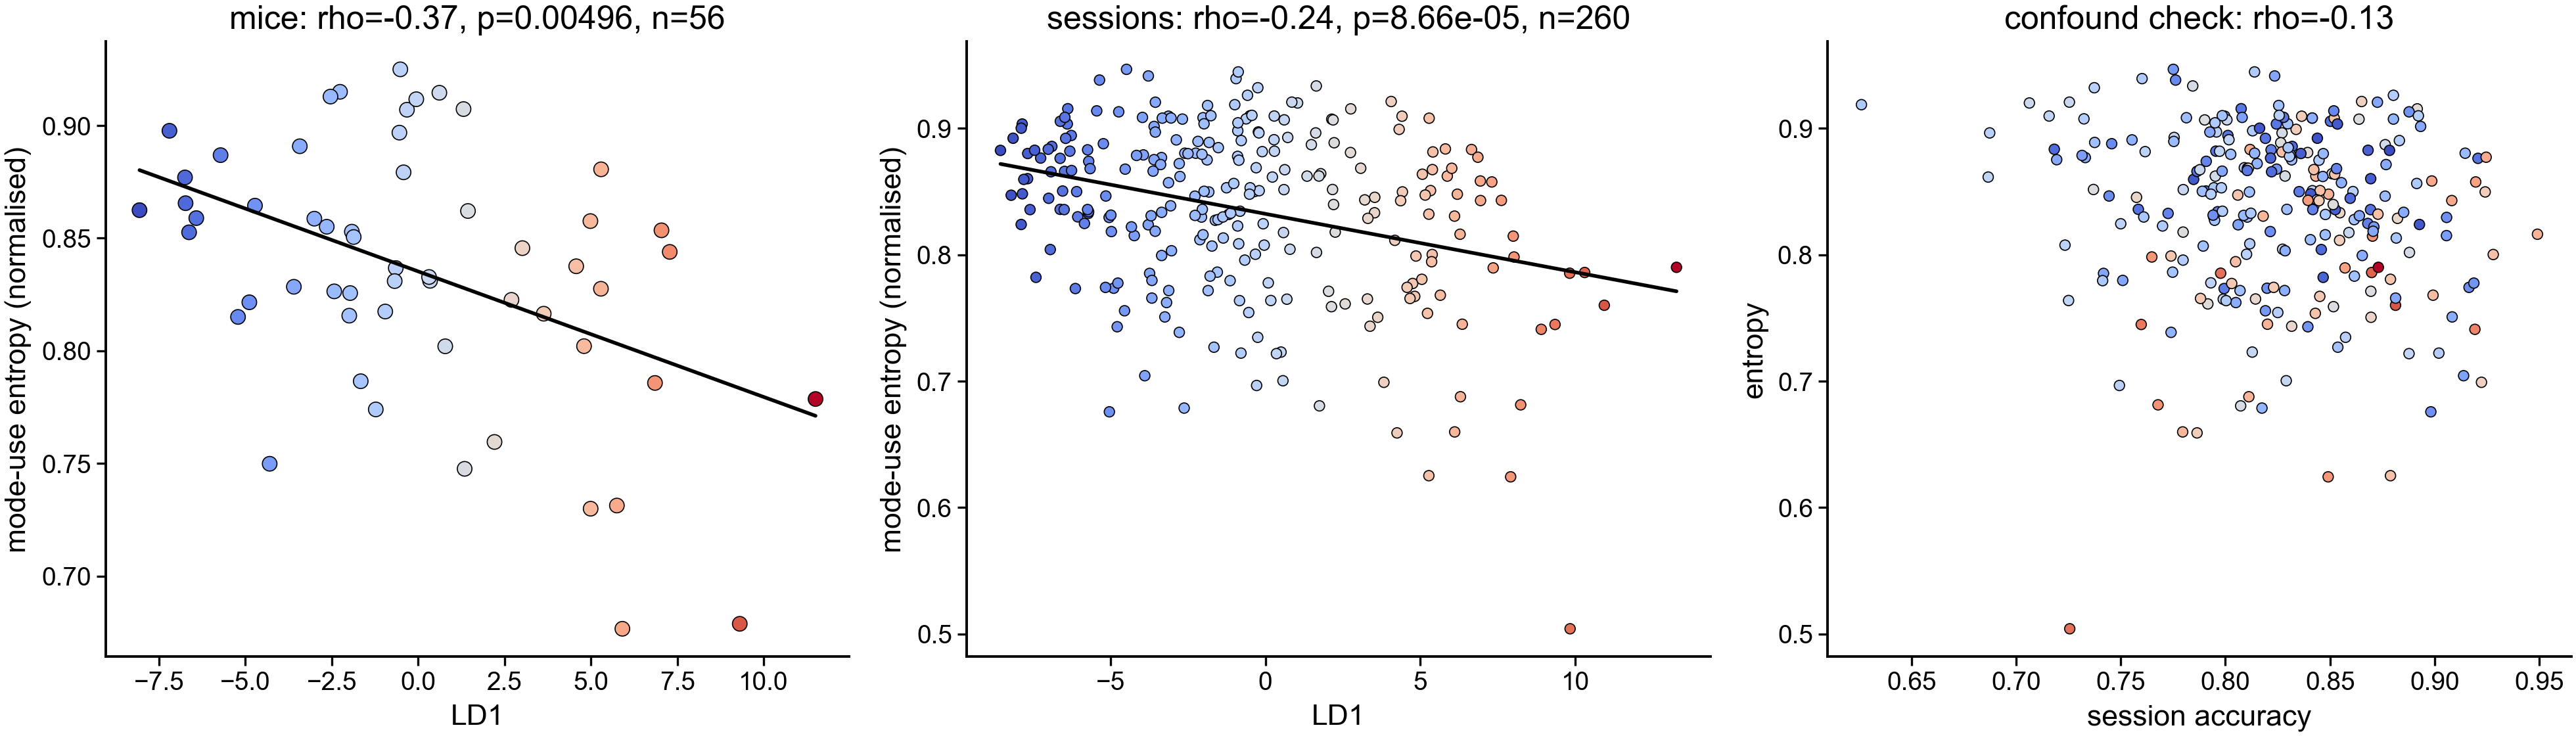

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (df, title) in zip(axes[:2], [(mouse, 'mice'), (sess, 'sessions')]):
    ax.scatter(df['lda_1'], df['H'], c=df['lda_1'], cmap=ps.LD1_CMAP, s=16 if title == 'mice' else 8,
               edgecolor='k', lw=0.3)
    r = spearmanr(df['lda_1'], df['H'])
    if r.pvalue < 0.05:
        a, b = np.polyfit(df['lda_1'], df['H'], 1); xs = np.linspace(df['lda_1'].min(), df['lda_1'].max(), 50)
        ax.plot(xs, a * xs + b, color='k', lw=1)
    ax.set(xlabel='LD1', ylabel='mode-use entropy (normalised)', title=f'{title}: rho={r.statistic:.2f}, p={r.pvalue:.3g}, n={len(df)}')
ax = axes[2]
ax.scatter(sess['accuracy'], sess['H'], c=sess['lda_1'], cmap=ps.LD1_CMAP, s=8, edgecolor='k', lw=0.3)
r = spearmanr(sess['accuracy'], sess['H'])
ax.set(xlabel='session accuracy', ylabel='entropy', title=f'confound check: rho={r.statistic:.2f}')
fig.tight_layout(); plt.show()

## What drives it: which modes' usage changes along LD1?
Mouse-level Spearman between LD1 and each mode's usage fraction (FDR across modes), modes in colour order. Entropy rises along LD1 if usage moves from a few dominant modes to the rare ones.

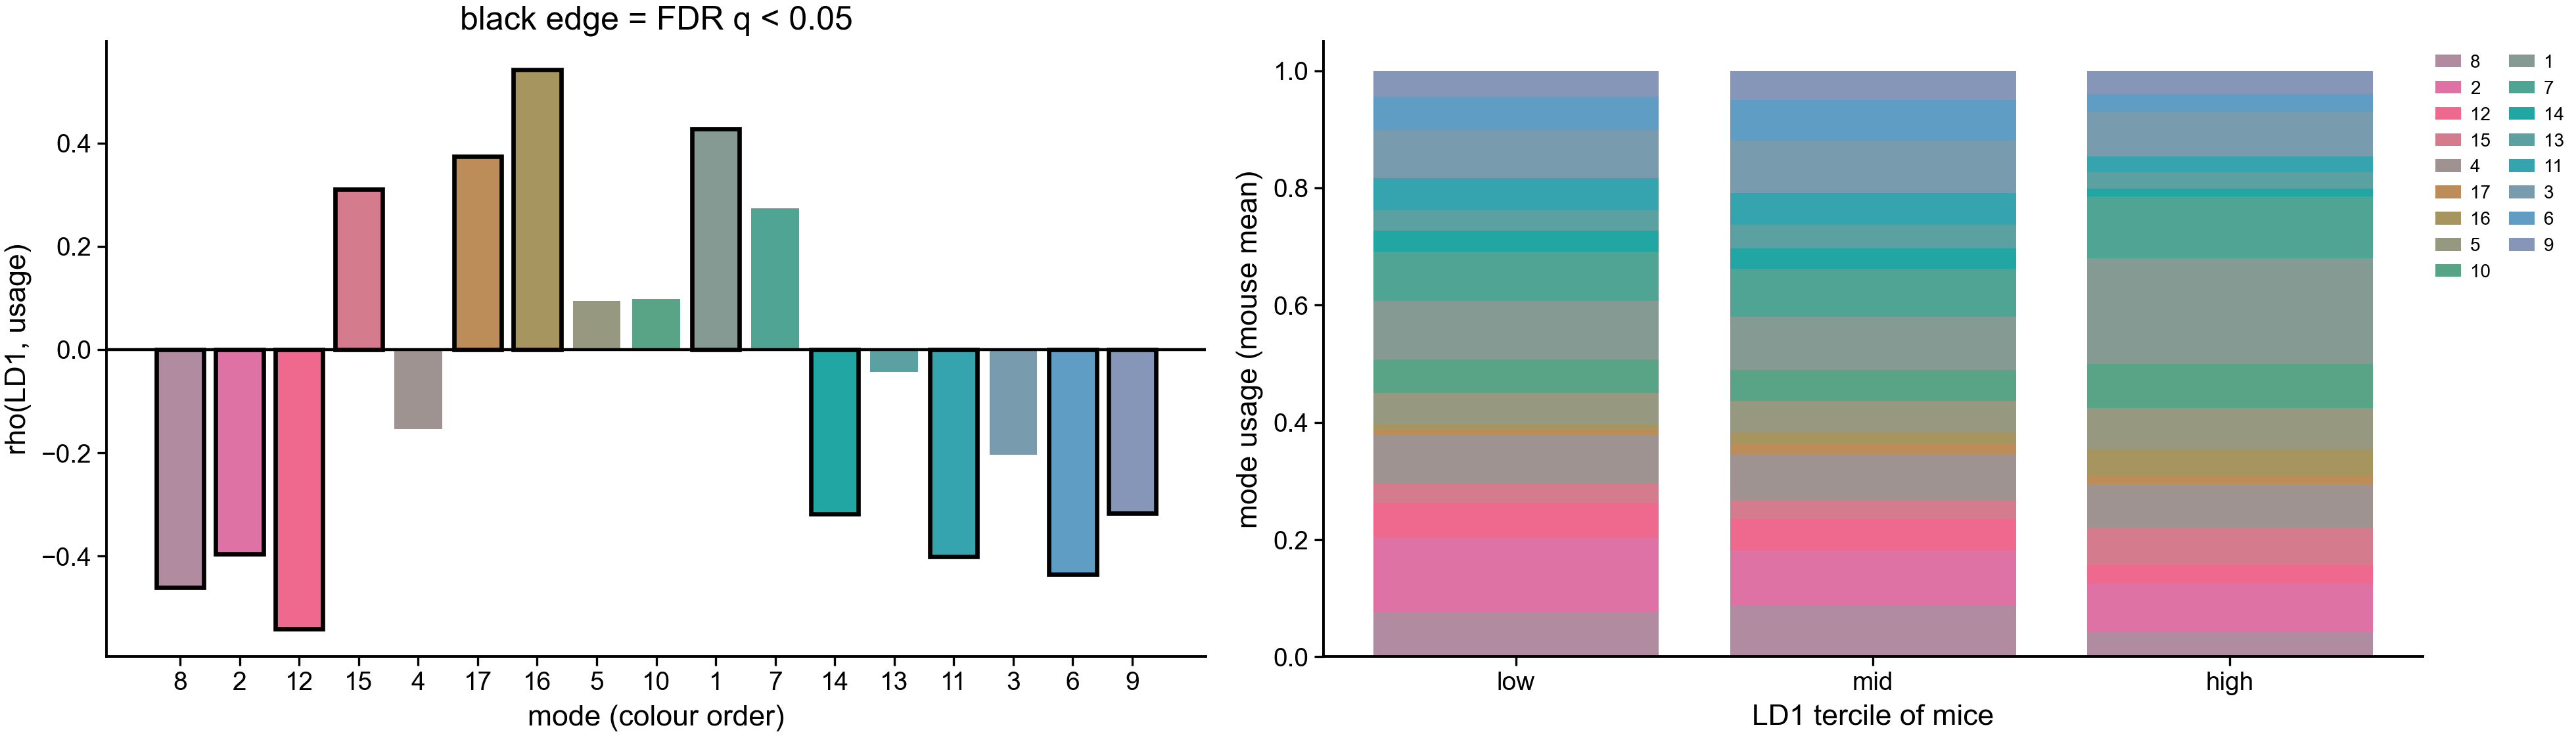

,mode,mean_use,rho,p,q
0,8,0.0678,-0.4604,0.0004,0.0020
1,2,0.1022,-0.3956,0.0025,0.0062
2,12,0.0480,-0.5407,0.0000,0.0001
3,15,0.0428,0.3107,0.0198,0.0305
4,4,0.0783,-0.1535,0.2586,0.3140
5,17,0.0145,0.3741,0.0045,0.0096
6,16,0.0247,0.5428,0.0000,0.0001
7,5,0.0588,0.0940,0.4908,0.5215
8,10,0.0616,0.0984,0.4708,0.5215
9,1,0.1244,0.4276,0.0010,0.0034


In [6]:
use_cols = [f'use_{k}' for k in ORDER]
mu = sess.groupby('mouse_name')[use_cols + ['lda_1']].mean()
rows = []
for k, c in zip(ORDER, use_cols):
    r = spearmanr(mu['lda_1'], mu[c]); rows.append(dict(mode=k, mean_use=mu[c].mean(), rho=r.statistic, p=r.pvalue))
modes_ld = pd.DataFrame(rows); modes_ld['q'] = multipletests(modes_ld['p'], method='fdr_bh')[1]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].bar([str(k) for k in ORDER], modes_ld['rho'], color=[MODE_COLORS[float(k)] for k in ORDER],
            edgecolor=['k' if q < 0.05 else 'none' for q in modes_ld['q']], lw=1.2)
axes[0].axhline(0, color='k', lw=0.8); axes[0].set(xlabel='mode (colour order)', ylabel='rho(LD1, usage)', title='black edge = FDR q < 0.05')
# usage profile along LD1 terciles of mice
mu['ld1_bin'] = pd.qcut(mu['lda_1'], 3, labels=['low', 'mid', 'high'])
prof = mu.groupby('ld1_bin', observed=True)[use_cols].mean()
bottom = np.zeros(len(prof))
for k, c in zip(ORDER, use_cols):
    axes[1].bar(prof.index.astype(str), prof[c], bottom=bottom, color=MODE_COLORS[float(k)], label=str(k)); bottom += prof[c].to_numpy()
axes[1].set(ylabel='mode usage (mouse mean)', xlabel='LD1 tercile of mice')
axes[1].legend(fontsize=5, ncol=2, frameon=False, bbox_to_anchor=(1, 1))
fig.tight_layout(); plt.show()
modes_ld.round(4)

# Temporal structure: mutual information and stickiness, along LD1 and LD2

Entropy above ignores order. Two measures that don't:

* **Mutual information** between the modes of consecutive trials, I(mode_t; mode_t+1) = how many nats the current mode tells you about the next. Independent of how many modes a session uses (unlike conditional entropy, which inherits the entropy result).
* **Stickiness** = P(next trial is in the same mode).

Both are reported as **excess over a shuffle null** (`N_PERM` permutations of the session's mode labels). Plug-in MI from a 17 × 17 table of ~400–600 pairs is biased upwards; the shuffle has the same bias, so the difference removes it. Two nulls:

* **global**: shuffle across the whole session — any sequential structure counts, including slow drift (e.g. satiety changing mode use over the session);
* **local**: shuffle only within blocks of `BLOCK` trials — keeps slow drift, so what is left is trial-to-trial structure.

Pairs are consecutive trial_ids with both trials in a mode (background / unembedded trials break the pair).

**Engagement confound.** The slow, error-prone modes (8, 12) cluster in time because disengaged bouts last several trials, which makes sessions with more disengagement look sticky. Checked three ways: partial on the session's fraction of disengaged trials (GLM-HMM), partial on accuracy, and an **engaged-only** version that uses only pairs where both trials are engaged.

In [7]:
N_PERM, BLOCK = 200, 20
states = pd.read_parquet(PI / 'GLM-HMM' / 'merged_behavioral_and_states.pqt', columns=['eid', 'p_state1'])
states['trial_id'] = states.groupby('eid').cumcount()
states['engaged'] = states['p_state1'] >= 0.5
eng = states.rename(columns={'eid': 'session'})[['session', 'trial_id', 'engaged']]

def pair_stats(a, b, K):
    # MI (nats) and P(same) from paired labels 1..K
    joint = np.bincount((a - 1) * K + (b - 1), minlength=K * K).reshape(K, K).astype(float)
    n = joint.sum()
    pj = joint / n
    pa, pb = pj.sum(1), pj.sum(0)
    nz = pj > 0
    mi = (pj[nz] * np.log(pj[nz] / np.outer(pa, pb)[nz])).sum()
    return mi, (a == b).mean()

def local_perm(x, rng, block):
    y = x.copy()
    for s in range(0, len(x), block):
        y[s:s + block] = rng.permutation(y[s:s + block])
    return y

rng = np.random.default_rng(SEED)
rows = []
for s, d in modes.groupby('session'):
    d = d.sort_values('trial_id')
    lab = d['trial_cluster'].to_numpy()
    tid = d['trial_id'].to_numpy()
    ok = np.diff(tid) == 1                       # consecutive trial pairs
    mi, same = pair_stats(lab[:-1][ok], lab[1:][ok], K)
    null_g = np.array([pair_stats(*(lambda p: (p[:-1][ok], p[1:][ok]))(rng.permutation(lab)), K) for _ in range(N_PERM)])
    null_l = np.array([pair_stats(*(lambda p: (p[:-1][ok], p[1:][ok]))(local_perm(lab, rng, BLOCK)), K) for _ in range(N_PERM)])
    # engaged-only pairs (both trials engaged), global null within those pairs' trials
    e = d.merge(eng, on=['session', 'trial_id'], how='left')['engaged'].astype('boolean').fillna(False).to_numpy(dtype=bool)
    ok_e = ok & e[:-1] & e[1:]
    if ok_e.sum() > 100:
        mi_e, same_e = pair_stats(lab[:-1][ok_e], lab[1:][ok_e], K)
        lab_e_idx = np.where(e)[0]
        null_e = []
        for _ in range(N_PERM):
            p = lab.copy(); p[lab_e_idx] = rng.permutation(lab[lab_e_idx])
            null_e.append(pair_stats(p[:-1][ok_e], p[1:][ok_e], K))
        null_e = np.array(null_e)
        mi_e_x, same_e_x = mi_e - null_e[:, 0].mean(), same_e - null_e[:, 1].mean()
    else:
        mi_e_x = same_e_x = np.nan
    rows.append(dict(session=s, n_pairs=int(ok.sum()), mi=mi, same=same,
                     mi_x_global=mi - null_g[:, 0].mean(), same_x_global=same - null_g[:, 1].mean(),
                     mi_z_global=(mi - null_g[:, 0].mean()) / null_g[:, 0].std(),
                     mi_x_local=mi - null_l[:, 0].mean(), same_x_local=same - null_l[:, 1].mean(),
                     mi_x_engaged=mi_e_x, same_x_engaged=same_e_x,
                     frac_disengaged=1 - e.mean()))
seq = pd.DataFrame(rows).merge(sess[['session', 'mouse_name', 'lab', 'lda_1', 'lda_2', 'H', 'accuracy', 'n_trials']], on='session')
print(f"{len(seq)} sessions; sessions whose MI beats the global shuffle (z > 2): {(seq['mi_z_global'] > 2).mean():.0%}")
seq[['mi', 'mi_x_global', 'mi_x_local', 'mi_x_engaged', 'same', 'same_x_global', 'same_x_local', 'same_x_engaged', 'frac_disengaged']].describe().round(4)

260 sessions; sessions whose MI beats the global shuffle (z > 2): 86%


,mi,mi_x_global,mi_x_local,mi_x_engaged,same,same_x_global,same_x_local,same_x_engaged,frac_disengaged
count,260.0000,260.0000,260.0000,243.0000,260.0000,260.0000,260.0000,243.0000,260.0000
mean,0.2725,0.0778,0.0328,0.0704,0.1726,0.0523,0.0133,0.0483,0.1873
std,0.0904,0.0587,0.0293,0.0565,0.0567,0.0333,0.0193,0.0320,0.2497
min,0.0995,-0.0202,-0.0330,-0.0403,0.0667,-0.0418,-0.0488,-0.0520,0.0000
25%,0.2081,0.0391,0.0152,0.0345,0.1336,0.0299,0.0007,0.0274,0.0412
50%,0.2616,0.0616,0.0285,0.0554,0.1614,0.0466,0.0128,0.0447,0.0858
75%,0.3267,0.0991,0.0460,0.0888,0.1964,0.0696,0.0247,0.0660,0.2279
max,0.5797,0.3624,0.2103,0.3858,0.5272,0.1678,0.0939,0.1646,1.0000


### Against LD1 and LD2 (Spearman; mice = headline)

In [8]:
METRICS = ['mi_x_global', 'mi_x_local', 'mi_x_engaged', 'same_x_global', 'same_x_local', 'same_x_engaged']
mouse_seq = seq.groupby('mouse_name').agg(lab=('lab', 'first'), lda_1=('lda_1', 'mean'), lda_2=('lda_2', 'mean'),
                                          accuracy=('accuracy', 'mean'), frac_disengaged=('frac_disengaged', 'mean'),
                                          n_trials=('n_trials', 'mean'),
                                          **{m: (m, 'mean') for m in METRICS}).reset_index()

def tests(df, ld, m):
    d = df.dropna(subset=[m])
    out = {}
    r = spearmanr(d[ld], d[m]); out['raw'] = (r.statistic, r.pvalue)
    for name, ctrl in [('| frac_disengaged', ['frac_disengaged']), ('| accuracy', ['accuracy']), ('| n_trials', ['n_trials'])]:
        r = spearmanr(resid(d[ld].to_numpy(), [d[c] for c in ctrl]), resid(d[m].to_numpy(), [d[c] for c in ctrl]))
        out[name] = (r.statistic, r.pvalue)
    r = spearmanr(lab_centre(d, ld), lab_centre(d, m)); out['lab-centred'] = (r.statistic, r.pvalue)
    return out

rows = []
for level, df in [('mouse', mouse_seq), ('session', seq)]:
    for ld in ['lda_1', 'lda_2']:
        for m in METRICS:
            for t, (rho, p) in tests(df, ld, m).items():
                rows.append(dict(level=level, axis=ld, metric=m, test=t, rho=rho, p=p))
seq_res = pd.DataFrame(rows)
fam = (seq_res['level'] == 'mouse') & (seq_res['test'] == 'raw')
seq_res.loc[fam, 'q_fdr'] = multipletests(seq_res.loc[fam, 'p'], method='fdr_bh')[1]
show = seq_res[seq_res['level'] == 'mouse'].pivot_table(index=['axis', 'metric'], columns='test', values='rho')
showp = seq_res[seq_res['level'] == 'mouse'].pivot_table(index=['axis', 'metric'], columns='test', values='p')
print('MOUSE LEVEL, rho (p underneath); q_fdr is over the 12 raw mouse-level tests')
print(show[['raw', '| frac_disengaged', '| accuracy', '| n_trials', 'lab-centred']].round(3).to_string())
print(showp[['raw', '| frac_disengaged', '| accuracy', '| n_trials', 'lab-centred']].round(4).to_string())
print(seq_res.loc[fam, ['axis', 'metric', 'rho', 'p', 'q_fdr']].round(4).to_string(index=False))

MOUSE LEVEL, rho (p underneath); q_fdr is over the 12 raw mouse-level tests
test                    raw  | frac_disengaged  | accuracy  | n_trials  lab-centred
axis  metric                                                                       
lda_1 mi_x_engaged    0.162              0.184       0.200       0.204        0.251
      mi_x_global     0.154              0.177       0.155       0.172        0.272
      mi_x_local      0.161              0.177       0.174       0.211        0.261
      same_x_engaged  0.278              0.281       0.256       0.284        0.256
      same_x_global   0.260              0.266       0.249       0.289        0.261
      same_x_local    0.249              0.251       0.247       0.216        0.254
lda_2 mi_x_engaged    0.036              0.051       0.151       0.052        0.111
      mi_x_global     0.029              0.021       0.094       0.009        0.042
      mi_x_local     -0.008             -0.008       0.005      -0.006       -0.095


In [9]:
# within mouse: does a mouse's stickier session sit at a different LD position?
w = seq.copy()
for c in ['lda_1', 'lda_2'] + METRICS:
    w[c + '_c'] = w[c] - w.groupby('mouse_name')[c].transform('mean')
print('within-mouse (session minus its mouse mean), n =', len(w))
for ld in ['lda_1', 'lda_2']:
    for m in ['mi_x_local', 'same_x_local', 'mi_x_engaged']:
        d = w.dropna(subset=[m + '_c'])
        r = spearmanr(d[ld + '_c'], d[m + '_c'])
        print(f'  {ld} vs {m}: rho = {r.statistic:.3f}, p = {r.pvalue:.3g}')

within-mouse (session minus its mouse mean), n = 260
  lda_1 vs mi_x_local: rho = 0.054, p = 0.388
  lda_1 vs same_x_local: rho = 0.038, p = 0.544
  lda_1 vs mi_x_engaged: rho = -0.035, p = 0.591
  lda_2 vs mi_x_local: rho = -0.101, p = 0.105
  lda_2 vs same_x_local: rho = -0.171, p = 0.00581
  lda_2 vs mi_x_engaged: rho = -0.120, p = 0.0627


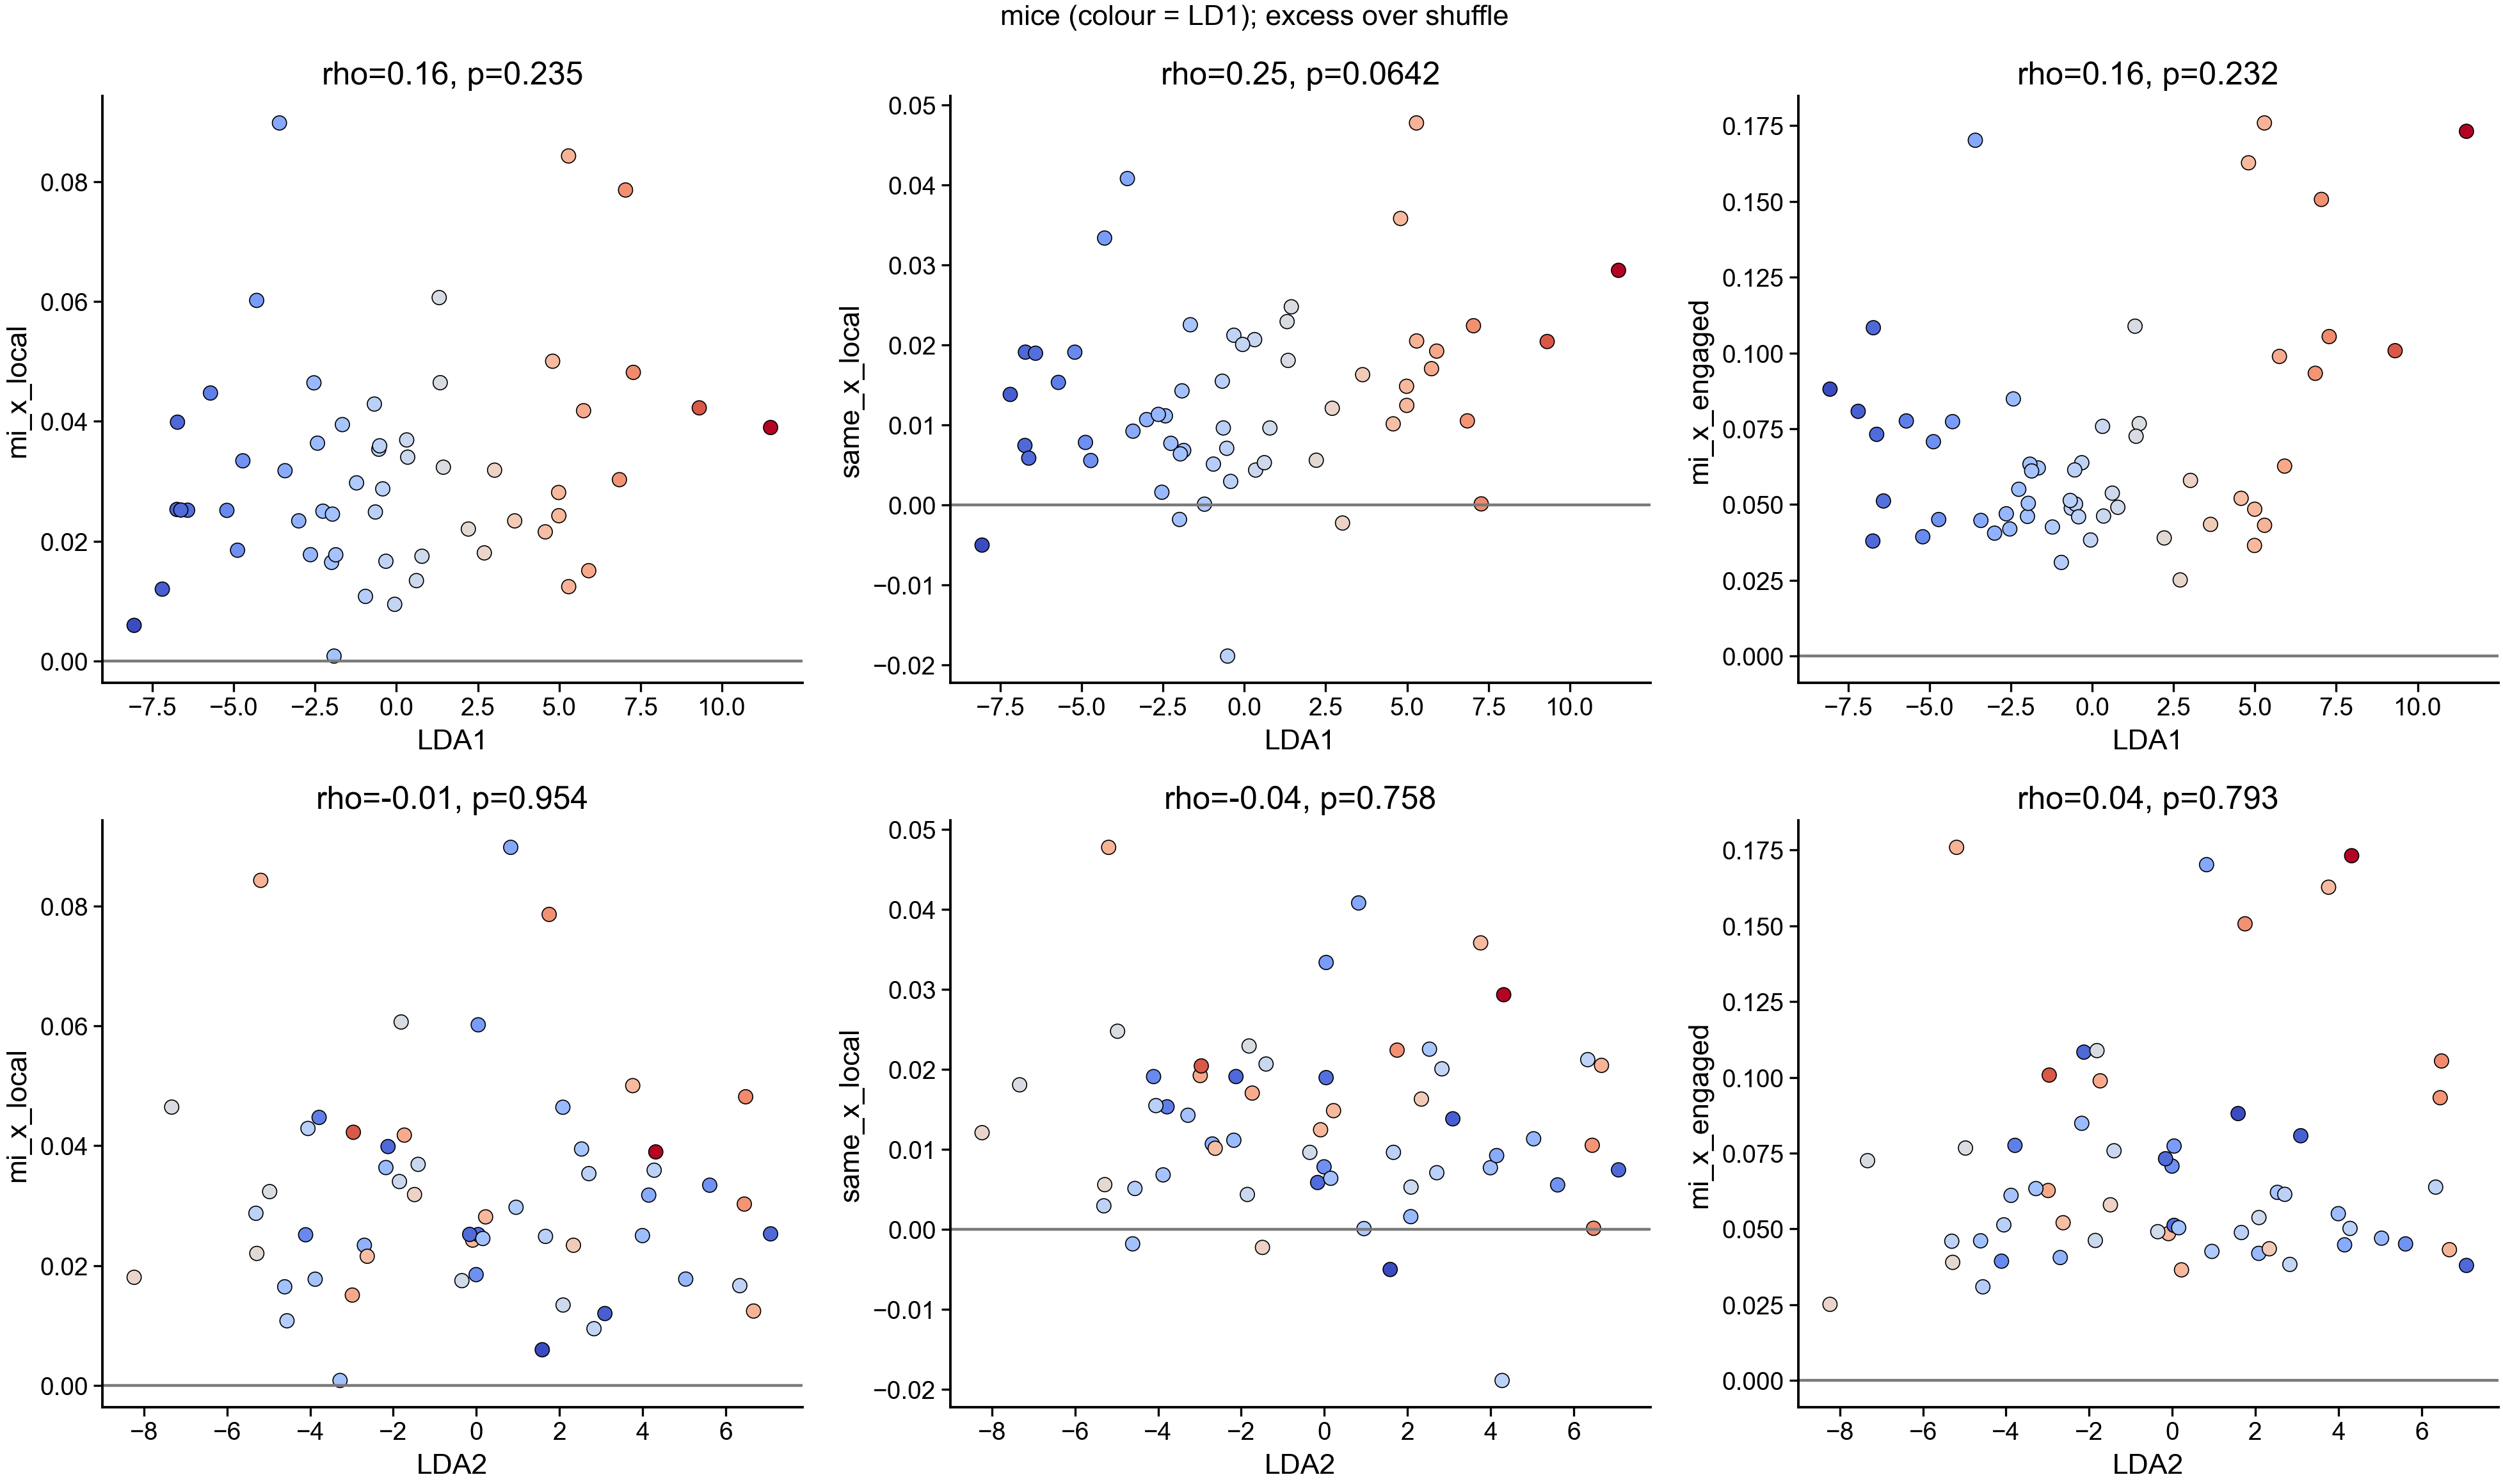

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for row, ld in enumerate(['lda_1', 'lda_2']):
    for col, m in enumerate(['mi_x_local', 'same_x_local', 'mi_x_engaged']):
        ax = axes[row, col]
        d = mouse_seq.dropna(subset=[m])
        ax.scatter(d[ld], d[m], c=d['lda_1'], cmap=ps.LD1_CMAP, s=16, edgecolor='k', lw=0.3)
        ax.axhline(0, color=ps.NEUTRAL, lw=0.8)
        r = spearmanr(d[ld], d[m])
        if r.pvalue < 0.05:
            a, b = np.polyfit(d[ld], d[m], 1); xs = np.linspace(d[ld].min(), d[ld].max(), 50); ax.plot(xs, a * xs + b, 'k', lw=1)
        ax.set(xlabel=ld.upper().replace('_', ''), ylabel=m, title=f'rho={r.statistic:.2f}, p={r.pvalue:.3g}')
fig.suptitle('mice (colour = LD1); excess over shuffle', fontsize=8)
fig.tight_layout(); plt.show()

### Which modes are sticky, and does that change along LD1 / LD2?
Per mode: P(next trial in the same mode | this trial in it) minus that mode's usage (its chance level), per session, averaged per mouse (sessions where the mode has ≥ 10 trials). Then Spearman with LD1 / LD2 across mice, FDR within each axis.

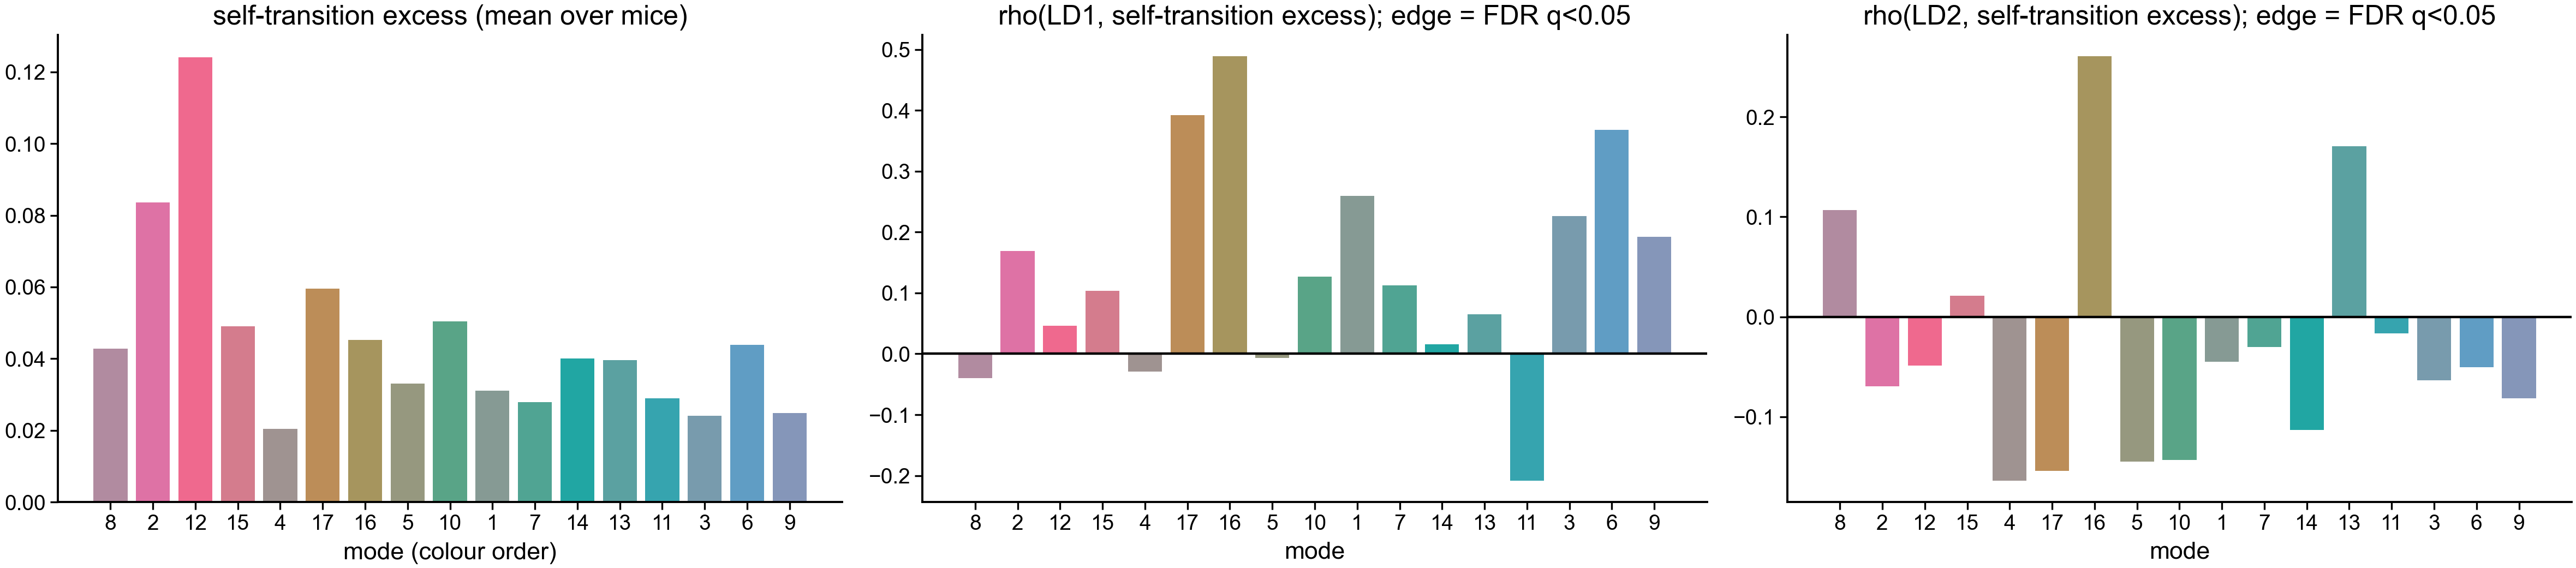

,mode,n_mice,mean_self_excess,rho_ld1,p_ld1,rho_ld2,p_ld2,q_ld1,q_ld2
0,8,53,0.0428,-0.0395,0.7788,0.1069,0.4461,0.9457,0.9055
1,2,55,0.0836,0.1690,0.2173,-0.0697,0.6131,0.4617,0.9055
2,12,54,0.1241,0.0458,0.7424,-0.0490,0.7250,0.9457,0.9055
3,15,54,0.0491,0.1034,0.4568,0.0209,0.8806,0.7060,0.9077
4,4,55,0.0204,-0.0287,0.8351,-0.1641,0.2311,0.9465,0.9055
5,17,23,0.0596,0.3923,0.0641,-0.1542,0.4825,0.2724,0.9055
6,16,27,0.0452,0.4890,0.0096,0.2607,0.1891,0.0819,0.9055
7,5,54,0.0331,-0.0071,0.9596,-0.1448,0.2961,0.9596,0.9055
8,10,55,0.0504,0.1271,0.3550,-0.1431,0.2971,0.6706,0.9055
9,1,55,0.0311,0.2591,0.0561,-0.0447,0.7457,0.2724,0.9055


In [11]:
rows = []
for s, d in modes.groupby('session'):
    d = d.sort_values('trial_id')
    lab = d['trial_cluster'].to_numpy(); ok = np.diff(d['trial_id'].to_numpy()) == 1
    a, b = lab[:-1][ok], lab[1:][ok]
    for k in range(1, K + 1):
        nk = (a == k).sum()
        if nk >= 10:
            rows.append(dict(session=s, mode=k, self_x=(b[a == k] == k).mean() - (lab == k).mean()))
selfx = pd.DataFrame(rows).merge(sess[['session', 'mouse_name', 'lda_1', 'lda_2']], on='session')
mself = selfx.groupby(['mouse_name', 'mode']).agg(self_x=('self_x', 'mean'), lda_1=('lda_1', 'mean'), lda_2=('lda_2', 'mean')).reset_index()
rows = []
for k in ORDER:
    d = mself[mself['mode'] == k]
    r1, r2 = spearmanr(d['lda_1'], d['self_x']), spearmanr(d['lda_2'], d['self_x'])
    rows.append(dict(mode=k, n_mice=len(d), mean_self_excess=d['self_x'].mean(), rho_ld1=r1.statistic, p_ld1=r1.pvalue,
                     rho_ld2=r2.statistic, p_ld2=r2.pvalue))
per_mode = pd.DataFrame(rows)
for ax_ in ['ld1', 'ld2']:
    per_mode[f'q_{ax_}'] = multipletests(per_mode[f'p_{ax_}'], method='fdr_bh')[1]
fig, axes = plt.subplots(1, 3, figsize=(12, 2.8))
cols = [MODE_COLORS[float(k)] for k in ORDER]
axes[0].bar([str(k) for k in ORDER], per_mode['mean_self_excess'], color=cols)
axes[0].set(title='self-transition excess (mean over mice)', xlabel='mode (colour order)')
for ax, a in zip(axes[1:], ['ld1', 'ld2']):
    ax.bar([str(k) for k in ORDER], per_mode[f'rho_{a}'], color=cols,
           edgecolor=['k' if q < 0.05 else 'none' for q in per_mode[f'q_{a}']], lw=1.2)
    ax.axhline(0, color='k', lw=0.8); ax.set(title=f'rho({a.upper()}, self-transition excess); edge = FDR q<0.05', xlabel='mode')
fig.tight_layout(); plt.show()
per_mode.round(4)

# Does the entropy result hold with syllables instead of trial modes?

Same question one level down: how evenly does a session spread its **10-bin syllables** over the 32 codes (paw × whisk × lick)? Also per epoch, and for the paw state alone (8 states, whisk/lick ignored), to see where any effect sits.

Same conventions as above: each session subsampled to `N_TRIALS` trials (`N_SUB_SYL` draws), entropy normalised by log(number of codes), mice as the unit, same controls.

**Circularity is stronger here than for modes.** LD1 is a linear read-out of per-epoch syllable *usage*, and entropy is a (nonlinear) function of that same usage. A correlation is therefore expected to some extent by construction; what is informative is its sign and where (which epoch / which part of the code) it comes from. Trial modes were one step removed (clusters of whole trial sequences), so the mode result above is the less circular of the two.

In [12]:
N_SUB_SYL = 50
syl = pd.read_parquet(PI / 'clustering' / 'data_files' / '8_k_10_bin_syllables_02-10-2026')
syl['session'] = syl['sample'].str.split().str[0]
syl['trial_id'] = syl['sample'].str.split().str[1].astype(float).astype(int)
syl = syl[syl['session'].isin(sess['session'])]
codes = ps.paw_codes(np.stack(syl['binned_sequence'].to_numpy()).astype(float))   # undo the paw relabelling
syl_epochs = syl['broader_label'].to_numpy()
EP = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']

def norm_H(x, m):
    x = x[~np.isnan(x)].astype(int)
    p = np.bincount(x, minlength=m) / len(x)
    p = p[p > 0]
    return -(p * np.log(p)).sum() / np.log(m)

rng = np.random.default_rng(SEED)
rows = []
for s, idx in syl.groupby('session').indices.items():
    tids = syl['trial_id'].to_numpy()[idx]
    uniq = np.unique(tids)
    acc = {k: [] for k in ['H_syl', 'H_paw'] + [f'H_{e}' for e in EP]}
    for _ in range(N_SUB_SYL):
        pick = np.isin(tids, rng.choice(uniq, min(N_TRIALS, len(uniq)), replace=False))
        c, ep = codes[idx][pick], syl_epochs[idx][pick]
        acc['H_syl'].append(norm_H(c.ravel(), 32))
        acc['H_paw'].append(norm_H((c % 8).ravel(), 8))
        for e in EP:
            acc[f'H_{e}'].append(norm_H(c[ep == e].ravel(), 32))
    allc = codes[idx]
    rows.append(dict(session=s, **{k: np.mean(v) for k, v in acc.items()},
                     whisk=np.nanmean((allc // 8) % 2 == 1), lick=np.nanmean(allc // 16 == 1)))
syl_H = pd.DataFrame(rows).merge(sess[['session', 'mouse_name', 'lab', 'lda_1', 'accuracy', 'n_trials', 'H']], on='session')
syl_H = syl_H.rename(columns={'H': 'H_modes'})
print(f'{len(syl_H)} sessions, {syl_H["mouse_name"].nunique()} mice')
syl_H[['H_syl', 'H_paw'] + [f'H_{e}' for e in EP] + ['whisk', 'lick', 'H_modes']].describe().round(3)

260 sessions, 56 mice


,H_syl,H_paw,H_Pre-quiescence,H_Quiescence,H_Choice,H_ITI,whisk,lick,H_modes
count,260.000,260.000,260.000,260.000,260.000,260.000,260.000,260.000,260.000
mean,0.714,0.796,0.576,0.466,0.709,0.717,0.589,0.197,0.835
std,0.043,0.045,0.098,0.078,0.056,0.035,0.118,0.081,0.067
min,0.593,0.620,0.330,0.272,0.536,0.572,0.367,0.040,0.504
25%,0.684,0.776,0.510,0.410,0.672,0.699,0.497,0.145,0.798
50%,0.717,0.804,0.593,0.468,0.714,0.721,0.576,0.190,0.848
75%,0.748,0.828,0.651,0.509,0.754,0.742,0.666,0.248,0.883
max,0.803,0.877,0.773,0.689,0.834,0.781,0.928,0.473,0.947


In [13]:
SYL_METRICS = ['H_modes', 'H_syl', 'H_paw'] + [f'H_{e}' for e in EP] + ['whisk', 'lick']
mouse_syl = syl_H.groupby('mouse_name').agg(lab=('lab', 'first'), lda_1=('lda_1', 'mean'), accuracy=('accuracy', 'mean'),
                                            n_trials=('n_trials', 'mean'), **{m: (m, 'mean') for m in SYL_METRICS}).reset_index()
rows = []
for m in SYL_METRICS:
    d = mouse_syl
    r = spearmanr(d['lda_1'], d[m]); row = dict(metric=m, rho=r.statistic, p=r.pvalue)
    r = spearmanr(resid(d['lda_1'].to_numpy(), [d['accuracy']]), resid(d[m].to_numpy(), [d['accuracy']])); row['rho | accuracy'] = r.statistic
    r = spearmanr(lab_centre(d, 'lda_1'), lab_centre(d, m)); row['rho lab-centred'] = r.statistic; row['p lab-centred'] = r.pvalue
    w = syl_H.assign(a=syl_H['lda_1'] - syl_H.groupby('mouse_name')['lda_1'].transform('mean'),
                     b=syl_H[m] - syl_H.groupby('mouse_name')[m].transform('mean'))
    r = spearmanr(w['a'], w['b']); row['rho within-mouse'] = r.statistic; row['p within-mouse'] = r.pvalue
    rows.append(row)
syl_res = pd.DataFrame(rows)
syl_res['q'] = multipletests(syl_res['p'], method='fdr_bh')[1]
print('MOUSE LEVEL (n = %d); within-mouse is session level' % len(mouse_syl))
print(syl_res.round(4).to_string(index=False))
print(f"\nmode entropy vs syllable entropy across mice: rho = {spearmanr(mouse_syl['H_modes'], mouse_syl['H_syl']).statistic:.2f}")

MOUSE LEVEL (n = 56); within-mouse is session level
          metric     rho      p  rho | accuracy  rho lab-centred  p lab-centred  rho within-mouse  p within-mouse      q
         H_modes -0.3703 0.0050         -0.3460          -0.4826         0.0002           -0.0015          0.9808 0.0112
           H_syl  0.2253 0.0950          0.2330           0.2315         0.0860            0.1971          0.0014 0.1425
           H_paw -0.0967 0.4783         -0.0738          -0.1280         0.3473            0.0073          0.9066 0.5380
H_Pre-quiescence -0.0509 0.7094         -0.0289          -0.0534         0.6960            0.1061          0.0878 0.7094
    H_Quiescence  0.4126 0.0016          0.4209           0.4575         0.0004            0.2619          0.0000 0.0047
        H_Choice -0.1592 0.2412         -0.1521          -0.1441         0.2894            0.0767          0.2176 0.3102
           H_ITI -0.3340 0.0119         -0.3287          -0.2360         0.0800           -0.1737    

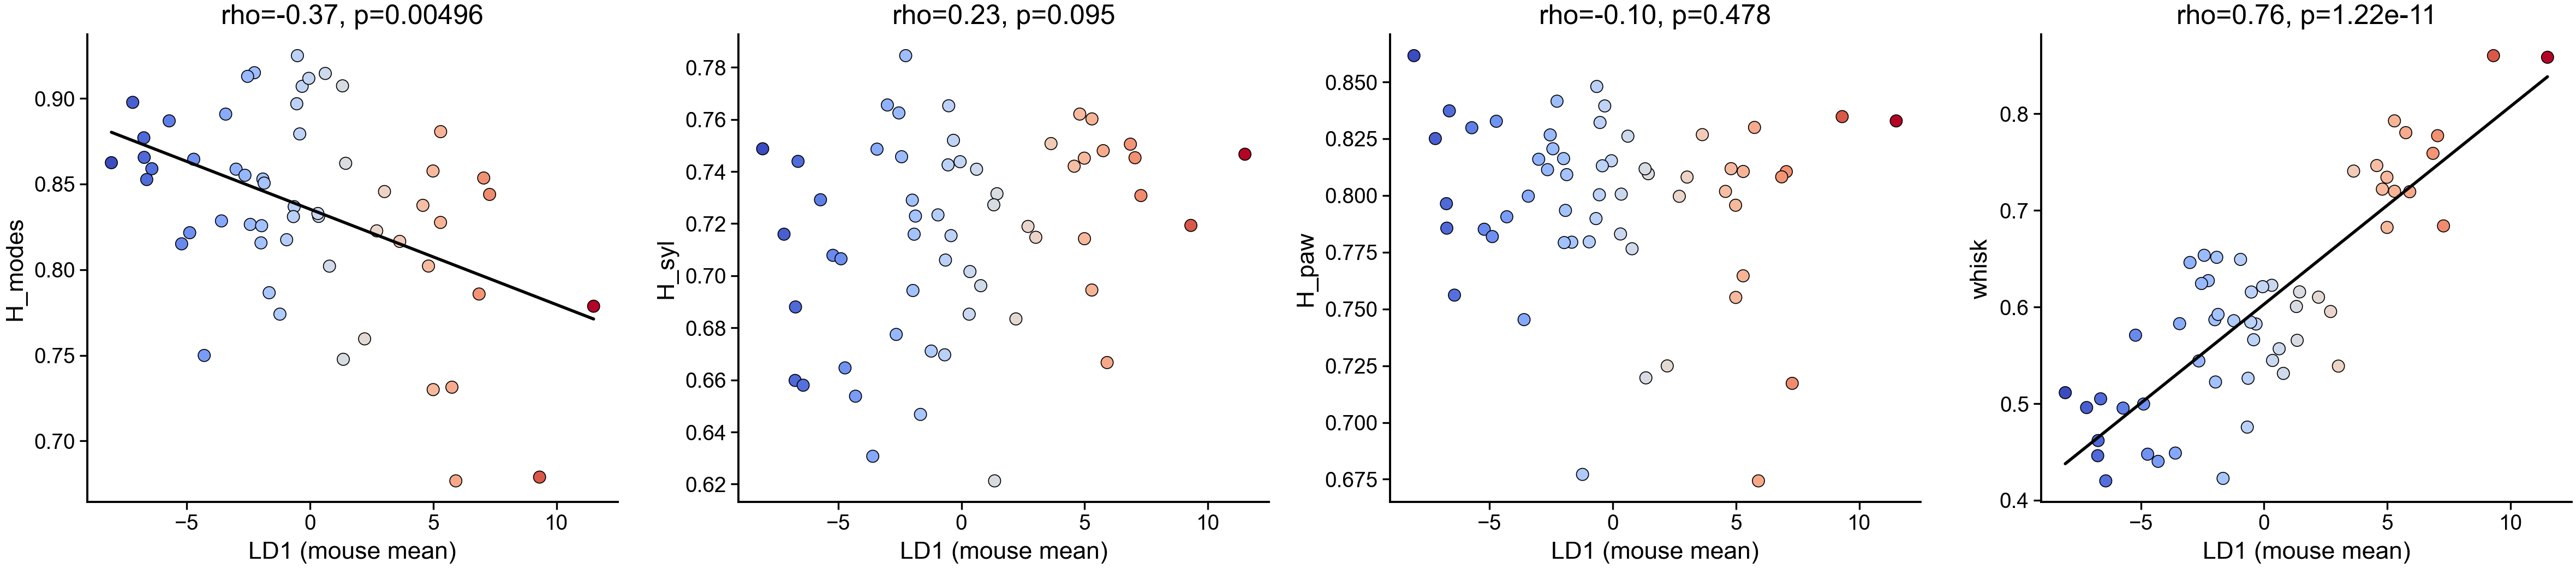

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
for ax, m in zip(axes, ['H_modes', 'H_syl', 'H_paw', 'whisk']):
    ax.scatter(mouse_syl['lda_1'], mouse_syl[m], c=mouse_syl['lda_1'], cmap=ps.LD1_CMAP, s=16, edgecolor='k', lw=0.3)
    r = spearmanr(mouse_syl['lda_1'], mouse_syl[m])
    if r.pvalue < 0.05:
        a, b = np.polyfit(mouse_syl['lda_1'], mouse_syl[m], 1); xs = np.linspace(mouse_syl['lda_1'].min(), mouse_syl['lda_1'].max(), 50)
        ax.plot(xs, a * xs + b, 'k', lw=1)
    ax.set(xlabel='LD1 (mouse mean)', ylabel=m, title=f'rho={r.statistic:.2f}, p={r.pvalue:.3g}')
fig.tight_layout(); plt.show()